lab notes at the end

# Time-Resolved ODMR Lab

## Setup

In [59]:
# Libraries
import pyvisa                    # Communication (also install pyvisa-py or NI VISA)
import matplotlib.pyplot as plt  # Plots
import numpy as np               # Maths
import pandas as pd              # DataFrames
import time                      # Delays
from tqdm.notebook import tqdm   # Progress bars (use 'for i in tqdm(iter)')
import os                        # Used for determining platform

In [60]:
# Device drivers
from Devices.LockIn import SR830M
from Devices.PicoPulse import PicoPulse
from Devices.LO import KuhnePLL

In [61]:
# Logging
import logging
logging.basicConfig(
    level = logging.INFO,
    format = '%(levelname)s - %(name)s - %(message)s',
    force = True
)
logger = logging.getLogger('TR-ODMR')

### Definitions

In [62]:
# Windows
# Find the COM port addresses of all three devices involved.
if os.name == 'nt':
    lockin_com = 8
    pico_com = 3
    osc_com = 4
    
    lockin_addr = f'ASRL{lockin_com}::INSTR'
    pico_addr = f'ASRL{pico_com}::INSTR'
    osc_addr = f'COM{osc_com}'

# Linux and MacOS
# Find the device files of the involved devices.
if os.name == 'posix':
    lockin_dev = '/dev/ttyUSB0'
    pico_dev = '/dev/ttyACM0'
    osc_dev = '/dev/ttyACM1'
        
    lockin_addr = f'ASRL{lockin_dev}::INSTR'
    pico_addr = f'ASRL{pico_dev}::INSTR'
    osc_addr = osc_dev

In [81]:
# This may also help
rm = pyvisa.ResourceManager()
print(rm.list_resources())
rm.close()

('ASRL/dev/ttyS31::INSTR', 'ASRL/dev/ttyS30::INSTR', 'ASRL/dev/ttyS29::INSTR', 'ASRL/dev/ttyS28::INSTR', 'ASRL/dev/ttyS27::INSTR', 'ASRL/dev/ttyS26::INSTR', 'ASRL/dev/ttyS25::INSTR', 'ASRL/dev/ttyS24::INSTR', 'ASRL/dev/ttyS23::INSTR', 'ASRL/dev/ttyS22::INSTR', 'ASRL/dev/ttyS21::INSTR', 'ASRL/dev/ttyS20::INSTR', 'ASRL/dev/ttyS19::INSTR', 'ASRL/dev/ttyS18::INSTR', 'ASRL/dev/ttyS17::INSTR', 'ASRL/dev/ttyS16::INSTR', 'ASRL/dev/ttyS15::INSTR', 'ASRL/dev/ttyS14::INSTR', 'ASRL/dev/ttyS13::INSTR', 'ASRL/dev/ttyS12::INSTR', 'ASRL/dev/ttyS11::INSTR', 'ASRL/dev/ttyS10::INSTR', 'ASRL/dev/ttyS9::INSTR', 'ASRL/dev/ttyS8::INSTR', 'ASRL/dev/ttyS7::INSTR', 'ASRL/dev/ttyS6::INSTR', 'ASRL/dev/ttyS5::INSTR', 'ASRL/dev/ttyS4::INSTR', 'ASRL/dev/ttyS3::INSTR', 'ASRL/dev/ttyS2::INSTR', 'ASRL/dev/ttyS1::INSTR', 'ASRL/dev/ttyS0::INSTR', 'ASRL/dev/ttyUSB0::INSTR', 'ASRL/dev/ttyACM1::INSTR', 'ASRL/dev/ttyACM0::INSTR')


/home/peter/Documents/proj/physeng_lab_reports/meas_env/lib64/python3.14/site-packages/pyvisa_py/tcpip.py:122: UserWarning: TCPIP::hislip resource discovery requires the zeroconf package to be installed... try 'pip install zeroconf'
  warnings.warn(


In [64]:
# pico-pulse pin mapping
# This is device-specific, you probably don't need to touch this.
pico_pins = {
    'lockin': 'ch1',
    'Q': 'ch2',
    'I': 'ch3',
    'laser': 'ch4'
}

## Basic usage

### pico-pulse

In [80]:
# Turn off laser

# Always instantiate a new resource manager and device object when starting a new cell
rm = pyvisa.ResourceManager()
pico = PicoPulse(rm, pico_addr, pico_pins)

idle_seq = pd.DataFrame(
        columns = ['time', 'lockin', 'laser'],
        data = [
            [1e6, 0, 0],
            [1e6, 1, 0],
        ]
    )

pico.sendSequence(idle_seq)

# Don't forget to close the resource manager
rm.close()

In [71]:
# Turn on laser

# Always instantiate a new resource manager and device object when starting a new cell
rm = pyvisa.ResourceManager()
pico = PicoPulse(rm, pico_addr, pico_pins)

adjust_seq = pd.DataFrame(
        columns = ['time', 'lockin', 'laser'],
        data = [
            [1e6, 0, 1],
            [1e6, 1, 1],
        ]
    )

pico.sendSequence(adjust_seq)

# Don't forget to close the resource manager
rm.close()

### SR830(M) lock-in amplifier

In [67]:
# Read single values from the lock-in

# Always instantiate a new resource manager and device object when starting a new cell
rm = pyvisa.ResourceManager()
lockin = SR830M(rm, lockin_addr)

# You can read just a single value
[ref] = lockin.snapshot('ref' )

# Or a list of values, up to 6 elements long
x, y, r, theta = lockin.snapshot(['x', 'y', 'r', 'theta'])

# Don't forget to close the resource manager
rm.close()
x, y, r, theta, ref

INFO - TR-ODMR.SR830M - Serial connection detected


(0.000546072, 1.17124e-05, 2.86103e-05, 19.44, 500.005)

In [ ]:
# Read out multiple values automatically.
# Useful for taking multiple measurements to integrate and calculate uncertainty.

# Always instantiate a new resource manager and device object when starting a new cell
rm = pyvisa.ResourceManager()
lockin = SR830M(rm, lockin_addr)

# Sample X and Y for 8 seconds with an automatic sample rate
# (calculated from time constant)
xs, ys = lockin.multiRead('x', 'y', 2)

# Sample AUX4 for 10 seconds at 4 Hz
# Setting channel 1 to None speeds up readout
_, aux4s = lockin.multiRead(None, 'aux4', 3, 4)

# Don't forget to close the resource manager
rm.close()
xs, ys, aux4s

### MW oscillator

In [23]:
# Instantiate a new one in each cell
osc = KuhnePLL(osc_addr)

# Self-explanatory. setMHz, set kHz and setHz methods are also available.
osc.setGHz(2.87)

# Make sure you delete it properly when you're done
del osc

## Task 3: CW Sequence Implementation and Optimization

In [ ]:
# Task 3: CW Sequence Implementation and Optimization

# 1. Initialize Devices
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)

    # 2. Set Microwave to resonance
    print("Setting LO to 2.87 GHz...")
    osc.setGHz(2.87)

    # 3. Define CW Sequence (T = 2 ms, 500 Hz modulation)
    # Mapping: ch1 -> lockin, ch2 -> Q, ch3 -> I, ch4 -> laser
    T = 2_000_000 # 2ms in ns
    cw_seq = pd.DataFrame(
        columns = ['time', 'lockin', 'Q', 'I', 'laser'],
        data = [
            [T/2, 1, 1, 1, 1], # First half: MW ON, Lock-in ON, Laser ON
            [T/2, 0, 0, 0, 1]  # Second half: MW OFF, Lock-in OFF, Laser ON
        ]
    )

    # 4. Send sequence and visualize
    print("Uploading CW sequence to PicoPulse...")
    pico.sendSequence(cw_seq)
    
    from Utilities.SequenceVisualizer import visSeqProportional
    visSeqProportional(cw_seq)

    # 5. Measure Signal
    print("Measuring lock-in signal (5s integration)...")
    time.sleep(1) # Settle time
    Rs, thetas = lockin.multiRead(ch1='R', ch2='THETA', t=5)
    
    print(f"Mean Signal R: {np.mean(Rs):.4f} V")
    print(f"Standard Deviation: {np.std(Rs):.4f} V")
    print(f"Mean Phase: {np.mean(thetas):.2f} deg")

finally:
    # Cleanup
    if 'osc' in locals(): del osc
    rm.close()

## Task 4: ODMR Frequency Sweep (Fixed tqdm)

INFO - TR-ODMR.SR830M - Serial connection detected


Sweeping 101 points (2.85-2.90 GHz)...


  0%|          | 0/101 [00:00<?, ?it/s]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  1%|          | 1/101 [00:02<04:40,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  2%|▏         | 2/101 [00:05<04:37,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  3%|▎         | 3/101 [00:08<04:34,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  4%|▍         | 4/101 [00:11<04:31,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  5%|▍         | 5/101 [00:14<04:29,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  6%|▌         | 6/101 [00:16<04:26,  2.80s/it]INFO - TR-ODMR.SR830M - Sample 

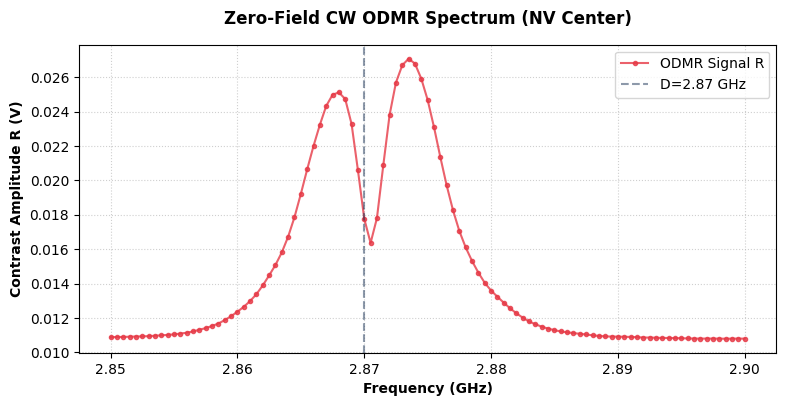

In [24]:
# Task 4: ODMR Frequency Sweep (Zero Magnetic Field)

# 1. Config
import tqdm
fs = np.linspace(2.85, 2.9, 101)
integrate_time, results = 2, []

# 2. Devices Setup
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)
    
    # Re-apply CW sequence from Task 3
    T = 2_000_000 # 2ms
    pico.sendSequence(pd.DataFrame(
        columns=['time', 'lockin', 'Q', 'I', 'laser'],
        data=[[T/2, 1, 1, 1, 1], [T/2, 0, 0, 0, 1]]
    ))

    print(f"Sweeping {len(fs)} points (2.85-2.90 GHz)...")
    # Using standard tqdm to avoid IProgress dependency
    for f in tqdm.tqdm(fs):
        osc.setGHz(f)
        time.sleep(0.1)
        Rs, _ = lockin.multiRead(ch1='R', t=integrate_time)
        results.append(np.mean(Rs))

    # 3. Data Export & Plotting
    os.makedirs('results', exist_ok=True)
    pd.DataFrame({'freq_GHz': fs, 'R_V': results}).to_csv('results/CW_SweepREDO.csv', index=False)

    plt.figure(figsize=(9, 4), dpi=100)
    plt.plot(fs, results, 'o-', color='#E63946', markersize=3, alpha=0.8, label='ODMR Signal R')
    plt.axvline(2.87, color='#1D3557', ls='--', alpha=0.5, label='D=2.87 GHz')
    plt.xlabel('Frequency (GHz)', fontweight='bold')
    plt.ylabel('Contrast Amplitude R (V)', fontweight='bold')
    plt.title('Zero-Field CW ODMR Spectrum (NV Center)', fontweight='bold', pad=15)
    plt.grid(True, ls=':', alpha=0.6)
    plt.legend()
    plt.savefig('results/CW_ODMR_Sweep.png', bbox_inches='tight')
    plt.show()
finally:
    if 'osc' in locals(): del osc
    rm.close()

INFO - TR-ODMR.SR830M - Serial connection detected


Sweeping 151 points (2.85-2.90 GHz)...


  0%|          | 0/151 [00:00<?, ?it/s]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  1%|          | 1/151 [00:02<07:00,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  1%|▏         | 2/151 [00:05<06:57,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  2%|▏         | 3/151 [00:08<06:54,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  3%|▎         | 4/151 [00:11<06:52,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  3%|▎         | 5/151 [00:14<06:49,  2.80s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
  4%|▍         | 6/151 [00:16<06:46,  2.80s/it]INFO - TR-ODMR.SR830M - Sample 

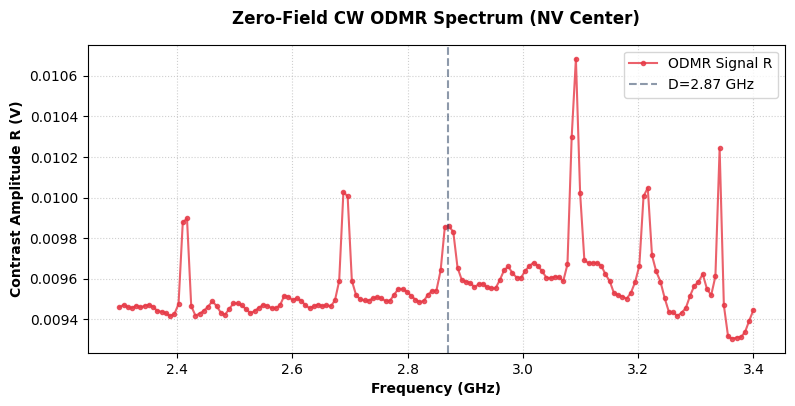

In [26]:
# Task 5: ODMR Frequency Sweep (with arb B)

# 1. Config
import tqdm
fs = np.linspace(2.3, 3.4, 151)
integrate_time, results = 2, []

# 2. Devices Setup
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)
    
    # Re-apply CW sequence from Task 3
    T = 2_000_000 # 2ms
    pico.sendSequence(pd.DataFrame(
        columns=['time', 'lockin', 'Q', 'I', 'laser'],
        data=[[T/2, 1, 1, 1, 1], [T/2, 0, 0, 0, 1]]
    ))

    print(f"Sweeping {len(fs)} points (2.85-2.90 GHz)...")
    # Using standard tqdm to avoid IProgress dependency
    for f in tqdm.tqdm(fs):
        osc.setGHz(f)
        time.sleep(0.1)
        Rs, _ = lockin.multiRead(ch1='R', t=integrate_time)
        results.append(np.mean(Rs))

    # 3. Data Export & Plotting
    os.makedirs('results', exist_ok=True)
    pd.DataFrame({'freq_GHz': fs, 'R_V': results}).to_csv('results/CW_Sweep_magnetREDO2.csv', index=False)

    plt.figure(figsize=(9, 4), dpi=100)
    plt.plot(fs, results, 'o-', color='#E63946', markersize=3, alpha=0.8, label='ODMR Signal R')
    plt.axvline(2.87, color='#1D3557', ls='--', alpha=0.5, label='D=2.87 GHz')
    plt.xlabel('Frequency (GHz)', fontweight='bold')
    plt.ylabel('Contrast Amplitude R (V)', fontweight='bold')
    plt.title('Zero-Field CW ODMR Spectrum (NV Center)', fontweight='bold', pad=15)
    plt.grid(True, ls=':', alpha=0.6)
    plt.legend()
    plt.savefig('results/CW_ODMR_Sweep_magnetREDO2.png', bbox_inches='tight')
    plt.show()
finally:
    if 'osc' in locals(): del osc
    rm.close()

In [ ]:
# now we repest but focusing only on one peak

# 1. Config
import tqdm
fs = np.linspace(3.04, 3.12, 51)
integrate_time, results = 2, []

# 2. Devices Setup
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)
    
    # Re-apply CW sequence from Task 3
    T = 2_000_000 # 2ms
    pico.sendSequence(pd.DataFrame(
        columns=['time', 'lockin', 'Q', 'I', 'laser'],
        data=[[T/2, 1, 1, 1, 1], [T/2, 0, 0, 0, 1]]
    ))

    print(f"Sweeping {len(fs)} points (2.85-2.90 GHz)...")
    # Using standard tqdm to avoid IProgress dependency
    for f in tqdm.tqdm(fs):
        osc.setGHz(f)
        time.sleep(0.1)
        Rs, _ = lockin.multiRead(ch1='R', t=integrate_time)
        results.append(np.mean(Rs))

    # 3. Data Export & Plotting
    os.makedirs('results', exist_ok=True)
    pd.DataFrame({'freq_GHz': fs, 'R_V': results}).to_csv('results/CW_Sweep_magnetFOCUS.csv', index=False)

    
finally:
    if 'osc' in locals(): del osc
    rm.close()

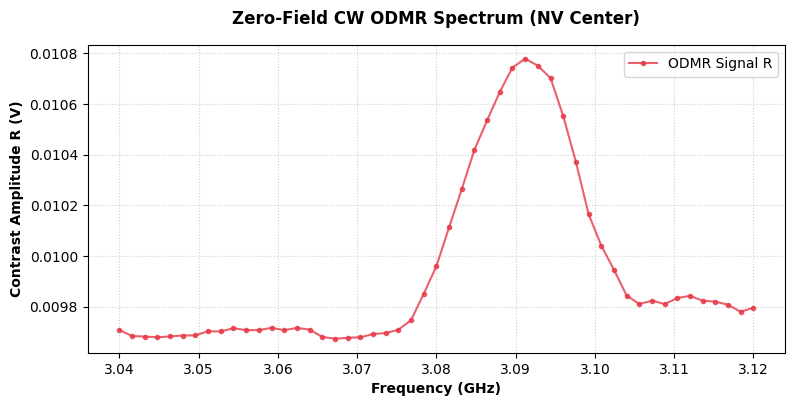

In [28]:
plt.figure(figsize=(9, 4), dpi=100)
plt.plot(fs, results, 'o-', color='#E63946', markersize=3, alpha=0.8, label='ODMR Signal R')
plt.xlabel('Frequency (GHz)', fontweight='bold')
plt.ylabel('Contrast Amplitude R (V)', fontweight='bold')
plt.title('Zero-Field CW ODMR Spectrum (NV Center)', fontweight='bold', pad=15)
plt.grid(True, ls=':', alpha=0.6)
plt.legend()
plt.savefig('results/CW_ODMR_Sweep_magnetFOCUS.png', bbox_inches='tight')
plt.show()

In [29]:
fs[np.argmax(results)]

np.float64(3.0912)

THUS we will focus on the f=3.0912   for the rabi oscillations in next task 

preliminary: workstation 1; sample d9 (NV) 

2
We connect the DETECTOR OUT to the back input of the lockin amplifier, which doesn't do any lock-in, it just does VOLMETER. We use it to calibrate.

We move the position of the sample to find the maximum photoluminescence signal. We do not move the mirror.

The background signal (before turning on the laser) is 0.22V

Max Achieved: 1.5 V


3

INFO - TR-ODMR.SR830M - Serial connection detected
WARNING - TR-ODMR.KuhnePLL - Sending command failed, retrying (attempt 1/3).
Setting LO to 2.87 GHz...
Uploading CW sequence to PicoPulse...


the lockin amplifier gives us the difference between the MW excited case and the non excited case:
we got higher difference, we are looking at the R of the lockin

lockin 
Mean Signal R: 0.0181 V
Standard Deviation: 0.0000 V
Mean Phase: -30.82 deg

this was before re-calibrating it.

now we re calibrate position of sample to maximize lockin signal

noise is about 0.1 mV

first run: R=18.5mV was max 

second run: R=18.3mV was max


So, in the photoluminescence case task 2, what you were trying to find is the location that has the highest density of nitrogen vacancy sites, because those are the photoluminescence emitting sites. And then, in the microwave case, because you are measuring the lock-in signal, which measures the difference in photoluminescence between the microwave excitation time and the non-microwave excitation time, then what you are trying to find is the space that has both the highest concentration of nitrogen vacancies, but also the highest intensity of the microwave field. And here we need to remember that both in this sample is inhomogeneous in space in the density and concentration of nitrogen vacancies, and the microwave is inhomogeneous in intensity because of the design.

4

time const is used from the lockin to calcuate the sampling rate

for task 2 and 3 we used 10ms, for task for onwards we use 30ms


2 groups of 4;

5

we redid task 5 both with and without arb magnetic field

6

first, sweep for tau
second, sweep for the amp MW excitation. we use an atenuator, which mske the mw wesker, making the B1 field weaker, making the frequency smaller



## Task 6: Rabi Oscillation Measurement

Generating pulse preview (2 MW cycles + 2 Ref cycles)...


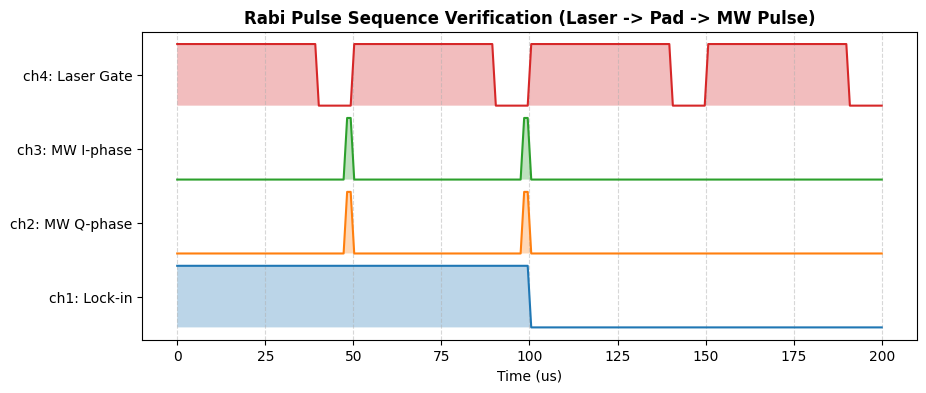

In [ ]:
# Task 6: Rabi 
import numpy as np
import matplotlib.pyplot as plt
from Utilities.UnitFormatting import getPrefix # already in meas_env

def custom_vis_rabi(seq):
    """Custom proportional visualizer with descriptive y-axis labels."""
    expand, data = 1e-3, {}
    ch_names = {
        'ch1': 'ch1: Lock-in',
        'ch2': 'ch2: MW Q-phase',
        'ch3': 'ch3: MW I-phase',
        'ch4': 'ch4: Laser Gate'
    }

    for ch in ["ch1", "ch2", "ch3", "ch4"]:
        if ch in seq:
            data[ch] = np.repeat(seq[ch], np.round(seq.time*expand))
        
    t_total = np.sum(seq.time)
    factor, prefix = getPrefix(t_total*1e-9)
    ts = np.linspace(0, t_total*1e-9/factor, round(t_total*expand)) 
        
    labels, centers = [], []
    plt.figure(figsize=(10, 4), dpi=100)
    for i, ch in enumerate(data):
        offset = i*1.2 + 0.2
        centers.append(offset + 0.5)
        plt.plot(ts, data[ch] + offset, label=ch_names[ch])
        plt.fill_between(ts, data[ch] + offset, offset, alpha=0.3)
        labels.append(ch_names[ch])
    
    plt.gca().set(yticks=centers, yticklabels=labels, xlabel=f"Time ({prefix}s)")
    plt.ylim(centers[0]-0.7, centers[-1]+0.7)
    plt.title('Rabi Pulse Sequence Verification (Laser -> Pad -> MW Pulse)', fontweight='bold')
    plt.grid(axis='x', ls='--', alpha=0.5)
    plt.show()

# Build the hardware-safe sequence
def preview_rabi_hardware(tau_ns, loops=2):
    t_dark, t_laser = 10000, 40000
    tpad = t_dark - tau_ns
    # hardware cols: ch1=lockin, ch2=Q, ch3=I, ch4=laser
    mw  = [[t_laser, 1, 0, 0, 1], [tpad, 1, 0, 0, 0], [tau_ns, 1, 1, 1, 0]] * loops
    ref = [[t_laser, 0, 0, 0, 1], [tpad, 0, 0, 0, 0], [tau_ns, 0, 0, 0, 0]] * loops
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3', 'ch4'])

print("Generating pulse preview (2 MW cycles + 2 Ref cycles)...")
seq = preview_rabi_hardware(tau_ns=1500, loops=2)
custom_vis_rabi(seq)

(this is just for visualization, ofc we are doing 50 cycles)

INFO - TR-ODMR.SR830M - Serial connection detected


Rabi sweep: Laser pulse FIRST (40.0us), then Dark, then MW.


Rabi Sweep:   0%|          | 0/100 [00:00<?, ?it/s]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   1%|          | 1/100 [00:04<08:13,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   2%|▏         | 2/100 [00:09<08:08,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   3%|▎         | 3/100 [00:14<08:03,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   4%|▍         | 4/100 [00:19<07:58,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   5%|▌         | 5/100 [00:24<07:53,  4.99s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi S

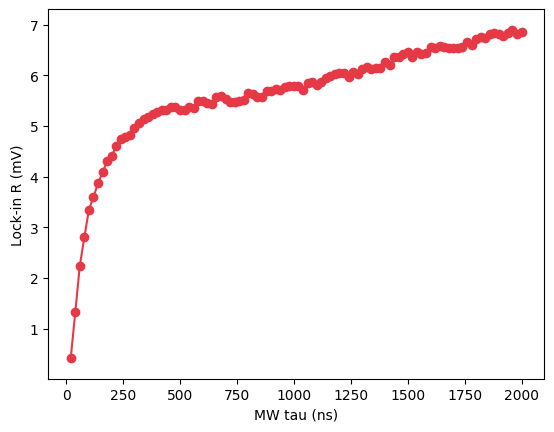

In [31]:
# Task 6: Rabi Measurement (Sweep - Corrected Order)
import tqdm as _tqdm

# --- Config (Fixed Order) ---
T_DARK_NS    = 10_000   # tpad + tau = 10 us
T_LASER_NS   = 40_000   # Readout pulse = 40 us
LOOPS        = 100      # reps per half-period
TAUS_NS      = np.arange(20, 2001, 20)  # tau = 20ns to 2us
INTEGRATE    = 3
SETTLE       = 1.0

def rabi_measurement_seq(tau):
    """Order: Laser -> Pad -> MW Pulse"""
    tpad = T_DARK_NS - tau
    # Columns: [time, ch1=lockin, ch2=Q, ch3=I, ch4=laser]
    mw  = [[T_LASER_NS, 1, 0, 0, 1], [tpad, 1, 0, 0, 0], [tau, 1, 1, 1, 0]] * LOOPS
    ref = [[T_LASER_NS, 0, 0, 0, 1], [tpad, 0, 0, 0, 0], [tau, 0, 0, 0, 0]] * LOOPS
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3', 'ch4'])

results = []
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)
    osc.setGHz(3.0912) # Tune resonance

    print(f"Rabi sweep: Laser pulse FIRST ({T_LASER_NS/1e3}us), then Dark, then MW.")
    for tau in _tqdm.tqdm(TAUS_NS, desc='Rabi Sweep'):
        pico.sendSequence(rabi_measurement_seq(tau))
        time.sleep(SETTLE)
        Rs, _ = lockin.multiRead(ch1='R', t=INTEGRATE)
        results.append({'tau_ns': tau, 'R_V': np.mean(Rs), 'Rstd': np.std(Rs)})

    # Save & Plot
    os.makedirs('results', exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv('results/Rabi_Corrected.csv', index=False)
    plt.errorbar(df.tau_ns, df.R_V*1000, yerr=df.Rstd*1000, fmt='o-', color='#E63946')
    plt.xlabel('MW tau (ns)'); plt.ylabel('Lock-in R (mV)'); plt.show()
finally:
    if 'osc' in locals(): del osc
    rm.close()

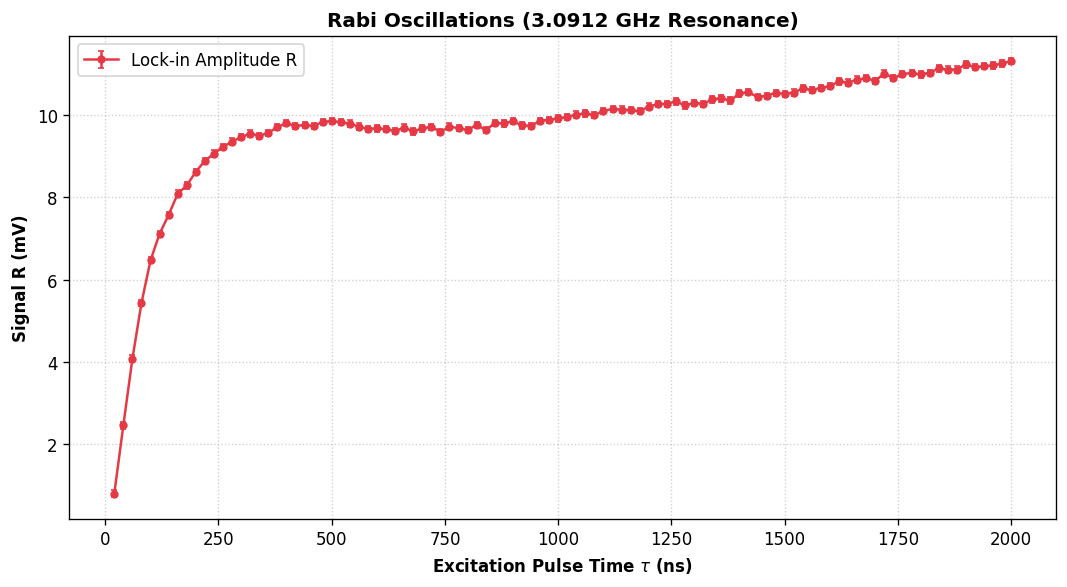

Successfully saved plot to: results/Rabi_tau1.png


In [40]:
# Task 6: Plotting & Export to Rabi_tau1.png
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Load the most recent result
csv_file = 'results/Rabi_tau1.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    
    # 2. Setup Plot
    plt.figure(figsize=(9, 5), dpi=120)
    plt.errorbar(df.tau_ns, df.R_V*1000, yerr=df.Rstd*1000, 
                 fmt='o-', color='#E63946', markersize=4, capsize=2, label='Lock-in Amplitude R')
    
    plt.xlabel(r'Excitation Pulse Time $\tau$ (ns)', fontweight='bold')
    plt.ylabel('Signal R (mV)', fontweight='bold')
    plt.title('Rabi Oscillations (3.0912 GHz Resonance)', fontweight='bold')
    plt.grid(True, ls=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    
    # 3. Save to Task 6 target location
    target_img = 'results/Rabi_tau1.png'
    plt.savefig(target_img, bbox_inches='tight')
    plt.show()
    
    print(f"Successfully saved plot to: {target_img}")
else:
    print(f"Error: {csv_file} not found. Please run the sweep cell first.")

this was too weak as we cant see the oscillations in the plot (and we cant apply the attenuator on this). we recalibrated the laser mirrors to get a stronger signal and the magnet too. we re do the measurement

INFO - TR-ODMR.SR830M - Serial connection detected


Rabi sweep: Laser pulse FIRST (40.0us), then Dark, then MW.


Rabi Sweep:   0%|          | 0/100 [00:00<?, ?it/s]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   1%|          | 1/100 [00:05<08:15,  5.01s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   2%|▏         | 2/100 [00:09<08:08,  4.99s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   3%|▎         | 3/100 [00:14<08:03,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   4%|▍         | 4/100 [00:19<07:58,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi Sweep:   5%|▌         | 5/100 [00:24<07:53,  4.98s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
Rabi S

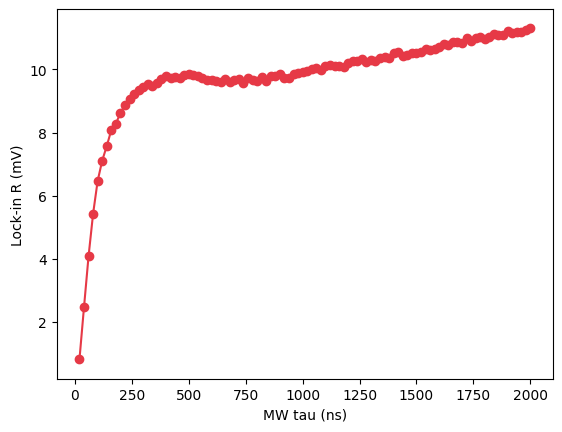

In [39]:
# Task 6: Rabi Measurement (Sweep - Corrected Order)
import tqdm as _tqdm

# --- Config (Fixed Order) ---
T_DARK_NS    = 10_000   # tpad + tau = 10 us
T_LASER_NS   = 40_000   # Readout pulse = 40 us
LOOPS        = 100      # reps per half-period
TAUS_NS      = np.arange(20, 2001, 20)  # tau = 20ns to 2us
INTEGRATE    = 3
SETTLE       = 1.0

def rabi_measurement_seq(tau):
    """Order: Laser -> Pad -> MW Pulse"""
    tpad = T_DARK_NS - tau
    # Columns: [time, ch1=lockin, ch2=Q, ch3=I, ch4=laser]
    mw  = [[T_LASER_NS, 1, 0, 0, 1], [tpad, 1, 0, 0, 0], [tau, 1, 1, 1, 0]] * LOOPS
    ref = [[T_LASER_NS, 0, 0, 0, 1], [tpad, 0, 0, 0, 0], [tau, 0, 0, 0, 0]] * LOOPS
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3', 'ch4'])

results = []
rm = pyvisa.ResourceManager()
try:
    osc = KuhnePLL(osc_dev)
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)
    osc.setGHz(3.0912) # Tune resonance

    print(f"Rabi sweep: Laser pulse FIRST ({T_LASER_NS/1e3}us), then Dark, then MW.")
    for tau in _tqdm.tqdm(TAUS_NS, desc='Rabi Sweep'):
        pico.sendSequence(rabi_measurement_seq(tau))
        time.sleep(SETTLE)
        Rs, _ = lockin.multiRead(ch1='R', t=INTEGRATE)
        results.append({'tau_ns': tau, 'R_V': np.mean(Rs), 'Rstd': np.std(Rs)})

    # Save & Plot
    os.makedirs('results', exist_ok=True)
    df = pd.DataFrame(results)
    df.to_csv('results/Rabi_tau1.csv', index=False)
    plt.errorbar(df.tau_ns, df.R_V*1000, yerr=df.Rstd*1000, fmt='o-', color='#E63946')
    plt.xlabel('MW tau (ns)'); plt.ylabel('Lock-in R (mV)')
    plt.show()
# here
finally:
    if 'osc' in locals(): del osc
    rm.close()

/tmp/ipykernel_677074/1164763092.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


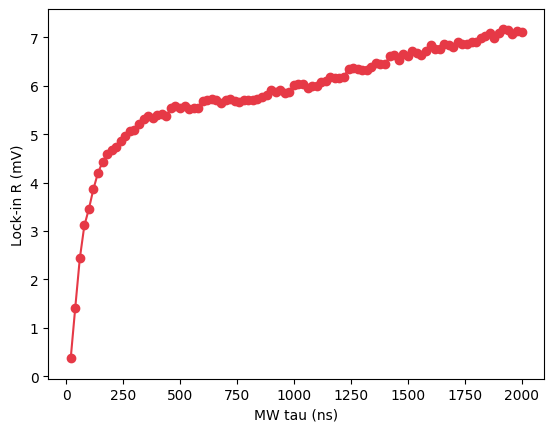

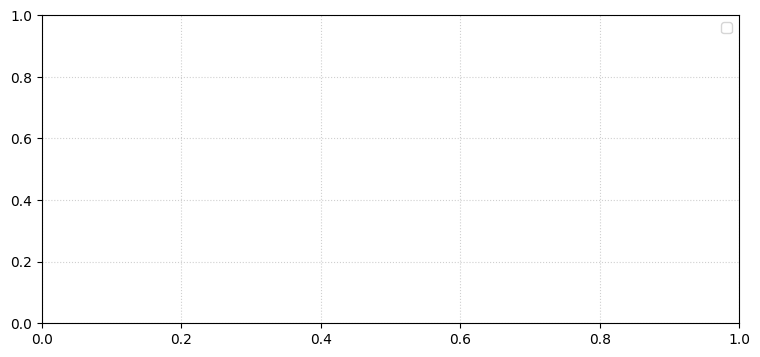

In [38]:

plt.errorbar(df.tau_ns, df.R_V*1000, yerr=df.Rstd*1000, fmt='o-', color='#E63946')
plt.xlabel('MW tau (ns)'); plt.ylabel('Lock-in R (mV)')
plt.figure(figsize=(9, 4), dpi=100)
plt.title('', fontweight='bold', pad=15)
plt.grid(True, ls=':', alpha=0.6)
plt.legend()
plt.savefig('results/Rabi_tau1.png', bbox_inches='tight')

## Task 7: $T_1$ Relaxation Measurement

**Objective**: Measure the longitudinal relaxation time $T_1$ of the NV center by observing the decay of spin polarization.

**Sequence Design**:
1. **Polarization ($t_{init}$)**: $50\text{ \mu s}$ laser pulse to initialize $S=0$ state.
2. **Relaxation ($\tau$)**: Variable dark time to allow return to thermal equilibrium.
3. **Readout ($t_{readout}$)**: $10\text{ \mu s}$ laser pulse to measure state occupancy.
4. **Padding ($t_{pad}$)**: Ensures constant total cycle length of $10\text{ ms}$ ($	au + t_{pad} = 10\text{ ms}$).

**Formula**: $V_R(\tau) = A e^{-\tau/T_1} + C$

Generating T1 Sequence Preview (tau = 2 ms)...


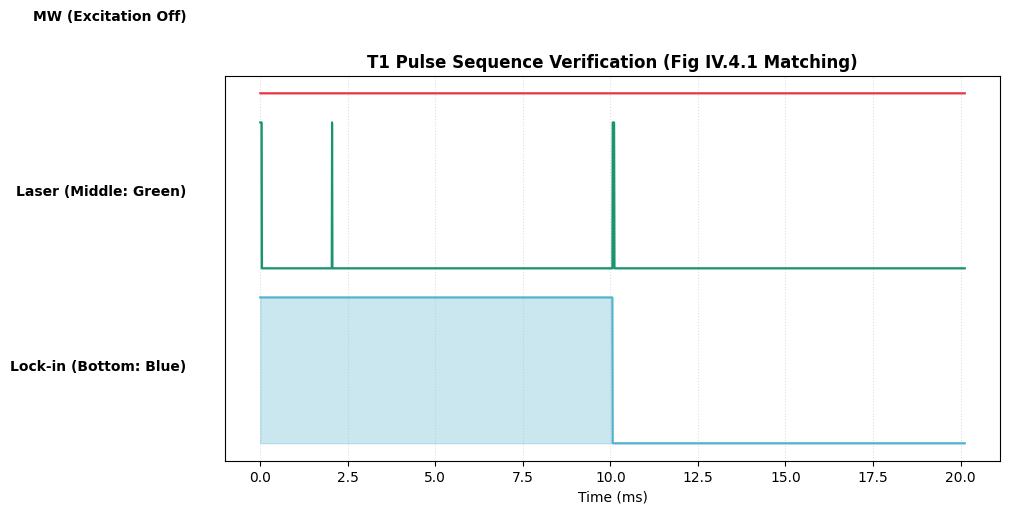

In [68]:
# Task 7 Verification: T1 Sequence Plot (Matching Fig IV.4.1)
import numpy as np
import matplotlib.pyplot as plt
from Utilities.UnitFormatting import getPrefix

def custom_vis_t1(seq):
    """Custom visualizer with FIG IV.4.1 order and color matching."""
    expand, data = 1e-4, {}
    ch_names = {
        'ch3': 'MW (Excitation Off)',
        'ch2': 'Laser (Middle: Green)',
        'ch1': 'Lock-in (Bottom: Blue)'
    }
    colors = {
        'ch3': '#E63946', # Orange/Red
        'ch2': '#1A936F', # Green
        'ch1': '#52B2CF'  # Blue
    }
    
    for ch in ["ch1", "ch2", "ch3"]:
        data[ch] = np.repeat(seq[ch], np.round(seq.time*expand))
        
    t_total = np.sum(seq.time)
    factor, prefix = getPrefix(t_total*1e-9)
    ts = np.linspace(0, t_total*1e-9/factor, round(t_total*expand)) 
        
    plt.figure(figsize=(10, 5), dpi=100)
    # Plot Bottom-to-Top (Order 1, 2, 3)
    for i, ch in enumerate(["ch1", "ch2", "ch3"]):
        offset = i*1.2 + 0.2
        plt.plot(ts, data[ch] + offset, color=colors[ch], lw=1.5)
        plt.fill_between(ts, data[ch] + offset, offset, color=colors[ch], alpha=0.3)
        plt.text(-0.05, offset + 0.5, ch_names[ch], weight='bold', ha='right', transform=plt.gca().get_yaxis_transform())
    
    plt.gca().set_yticks([])
    plt.xlabel(f"Time ({prefix}s)")
    plt.title('T1 Pulse Sequence Verification (Fig IV.4.1 Matching)', fontweight='bold')
    plt.grid(axis='x', ls=':', alpha=0.4)
    plt.show()

def preview_t1_validation(tau_ms=2):
    """Sequence builder for validation cell (2 loops for visibility)."""
    t_init, t_read = 50_000, 10_000
    t_cycle = 10_000_000
    tau = int(tau_ms * 1e6)
    tpad = t_cycle - tau
    
    # Mapping: ch1=Lockin, ch2=Laser, ch3=MW (remains 0)
    # mw_half contains both pulses; ref_half contains only Init (per T1.py & Fig labels)
    mw  = [[t_init, 1, 1, 0], [tau, 1, 0, 0], [t_read, 1, 1, 0], [tpad, 1, 0, 0]]
    ref = [[t_init, 0, 1, 0], [tau, 0, 0, 0], [t_read, 0, 0, 0], [tpad, 0, 0, 0]]
    
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3'])

print("Generating T1 Sequence Preview (tau = 2 ms)...")
val_seq = preview_t1_validation()
custom_vis_t1(val_seq)

INFO - TR-ODMR.SR830M - Serial connection detected


Starting T1 sweep: 50 points, 20ns to 3ms.


T1 Measurement:   0%|          | 0/50 [00:00<?, ?it/s]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
T1 Measurement:   2%|▏         | 1/50 [00:07<06:28,  7.93s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
T1 Measurement:   4%|▍         | 2/50 [00:15<06:21,  7.94s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
T1 Measurement:   6%|▌         | 3/50 [00:23<06:13,  7.94s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
T1 Measurement:   8%|▊         | 4/50 [00:31<06:05,  7.94s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, clamping it.
T1 Measurement:  10%|█         | 5/50 [00:39<05:57,  7.94s/it]INFO - TR-ODMR.SR830M - Sample rate is 32.0
INFO - TR-ODMR.SR830M - Requested too many points, c

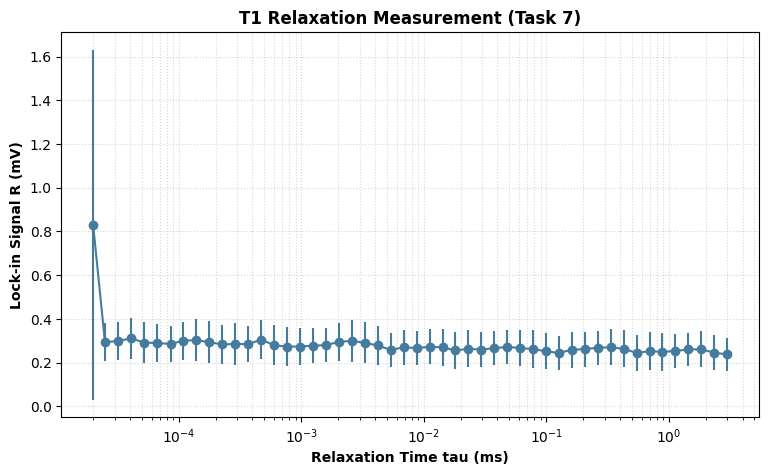


TIP: Fit with V(tau) = A * exp(-tau/T1) + C


In [72]:
# Task 7 Implementation: T1 Sweep
import numpy as np
import pandas as pd
import time
import tqdm

# --- Configuration (as per ODMR.md) ---
T_INIT_NS   = 50_000       # 50 us polarization
T_READOUT_NS = 10_000      # 10 us readout
T_CYCLE_NS  = 10_000_000   # tau + tpad = 10 ms (const)

# Sweep taus from 20 ns to 3 ms (Logarithmic sweep for decay curves)
TAUS_NS = np.geomspace(20, 3_000_000, 50).astype(int)

INTEGRATE = 5    # Lock-in integration (s)
SETTLE    = 1.5  # Settle time (s)

def t1_sequence(tau):
    """T1 Sequence: [Init -> Tau -> Readout -> Pad]"""
    tpad = T_CYCLE_NS - tau
    if tpad < 0:
        raise ValueError(f"tau={tau}ns is too large for 10ms cycle.")
    
    # Columns: [time, ch1=lockin, ch2=Q, ch3=I, ch4=laser]
    # Ref Half 1 (lockin=1): [Init (L:1) -> Tau (L:0) -> Readout (L:1) -> Pad (L:0)]
    mw  = [[T_INIT_NS, 1, 0, 0, 1], [tau, 1, 0, 0, 0], [T_READOUT_NS, 1, 0, 0, 1], [tpad, 1, 0, 0, 0]]
    
    # Ref Half 2 (lockin=0): Comparing (Init+Readout) to just (Init) 
    # based on T1.py logic: [Init (L:1) -> Tau (L:0) -> Readout (L:0) -> Pad (L:0)]
    ref = [[T_INIT_NS, 0, 0, 0, 1], [tau, 0, 0, 0, 0], [T_READOUT_NS, 0, 0, 0, 0], [tpad, 0, 0, 0, 0]]
    
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3', 'ch4'])

results_t1 = []
rm = pyvisa.ResourceManager()
try:
    # Note: For T1, Microwave should be OFF
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)

    print(f"Starting T1 sweep: {len(TAUS_NS)} points, 20ns to 3ms.")
    for tau in tqdm.tqdm(TAUS_NS, desc='T1 Measurement'):
        pico.sendSequence(t1_sequence(tau))
        time.sleep(SETTLE)
        Rs, _ = lockin.multiRead(ch1='R', t=INTEGRATE)
        results_t1.append({'tau_ns': tau, 'R_V': np.mean(Rs), 'Rstd': np.std(Rs)})

    # --- Save & Final Plot ---
    os.makedirs('results', exist_ok=True)
    df_t1 = pd.DataFrame(results_t1)
    df_t1.to_csv('results/T1_Sweep.csv', index=False)

    plt.figure(figsize=(9, 5), dpi=100)
    plt.errorbar(df_t1.tau_ns / 1e6, df_t1.R_V*1000, yerr=df_t1.Rstd*1000, 
                 fmt='o-', color='#457B9D', label='T1 Signal (mV)')
    plt.xscale('log')
    plt.xlabel('Relaxation Time tau (ms)', fontweight='bold')
    plt.ylabel('Lock-in Signal R (mV)', fontweight='bold')
    plt.title('T1 Relaxation Measurement (Task 7)', fontweight='bold')
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.savefig('results/T1_Final.png', bbox_inches='tight')
    plt.show()
    
    print("\nTIP: Fit with V(tau) = A * exp(-tau/T1) + C")
finally:
    rm.close()

INFO - TR-ODMR.SR830M - Serial connection detected


Starting T1 sweep: 50 points, 20ns to 3ms.


T1 Measurement: 100%|██████████| 50/50 [04:41<00:00,  5.64s/it]


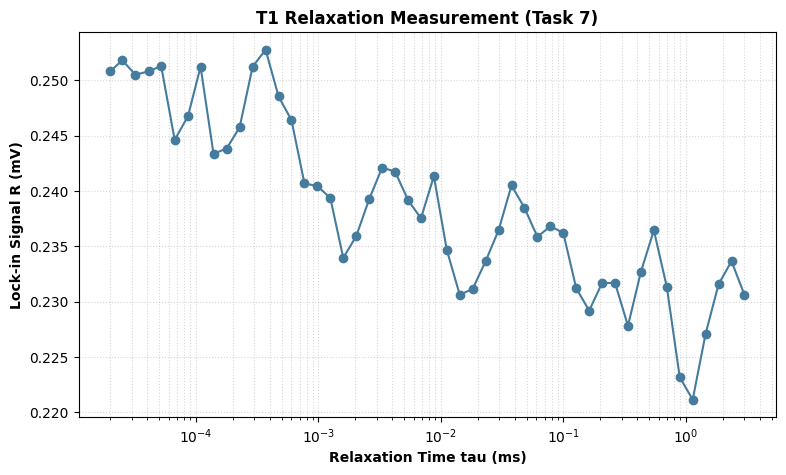


TIP: Fit with V(tau) = A * exp(-tau/T1) + C


In [79]:
# Task 7 Implementation: T1 Sweep
import numpy as np
import pandas as pd
import time
import tqdm

# --- Configuration (as per ODMR.md) ---
T_INIT_NS   = 50_000       # 50 us polarization
T_READOUT_NS = 10_000      # 10 us readout
T_CYCLE_NS  = 10_000_000   # tau + tpad = 10 ms (const)

# Sweep taus from 20 ns to 3 ms (Logarithmic sweep for decay curves)
TAUS_NS = np.geomspace(20, 3_000_000, 50).astype(int)

INTEGRATE = 4    # Lock-in integration (s)
SETTLE    = 1.5  # Settle time (s)

def t1_sequence(tau):
    """T1 Sequence: [Init -> Tau -> Readout -> Pad]"""
    tpad = T_CYCLE_NS - tau
    if tpad < 0:
        raise ValueError(f"tau={tau}ns is too large for 10ms cycle.")
    
    # Columns: [time, ch1=lockin, ch2=Q, ch3=I, ch4=laser]
    # Ref Half 1 (lockin=1): [Init (L:1) -> Tau (L:0) -> Readout (L:1) -> Pad (L:0)]
    mw  = [[T_INIT_NS, 1, 0, 0, 1], [tau, 1, 0, 0, 0], [T_READOUT_NS, 1, 0, 0, 1], [tpad, 1, 0, 0, 0]]
    
    # Ref Half 2 (lockin=0): Comparing (Init+Readout) to just (Init) 
    # based on T1.py logic: [Init (L:1) -> Tau (L:0) -> Readout (L:0) -> Pad (L:0)]
    ref = [[T_INIT_NS, 0, 0, 0, 1], [tau, 0, 0, 0, 0], [T_READOUT_NS, 0, 0, 0, 0], [tpad, 0, 0, 0, 0]]
    
    return pd.DataFrame(mw + ref, columns=['time', 'ch1', 'ch2', 'ch3', 'ch4'])

results_t1 = []
rm = pyvisa.ResourceManager()
try:
    # Note: For T1, Microwave should be OFF
    lockin = SR830M(rm, lockin_addr)
    pico = PicoPulse(rm, pico_addr, pico_pins)

    print(f"Starting T1 sweep: {len(TAUS_NS)} points, 20ns to 3ms.")
    for tau in tqdm.tqdm(TAUS_NS, desc='T1 Measurement'):
        pico.sendSequence(t1_sequence(tau))
        time.sleep(SETTLE)
        Rs, _ = lockin.multiRead(ch1='R', t=INTEGRATE)
        results_t1.append({'tau_ns': tau, 'R_V': np.mean(Rs), 'Rstd': np.std(Rs)})

    # --- Save & Final Plot ---
    os.makedirs('results', exist_ok=True)
    df_t1 = pd.DataFrame(results_t1)
    df_t1.to_csv('results/T1_Sweep2.csv', index=False)

    plt.figure(figsize=(9, 5), dpi=100)
    plt.errorbar(df_t1.tau_ns / 1e6, df_t1.R_V*1000, yerr=df_t1.Rstd*1000, 
                 fmt='o-', color='#457B9D', label='T1 Signal (mV)')
    plt.xscale('log')
    plt.xlabel('Relaxation Time tau (ms)', fontweight='bold')
    plt.ylabel('Lock-in Signal R (mV)', fontweight='bold')
    plt.title('T1 Relaxation Measurement (Task 7)', fontweight='bold')
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.savefig('results/T1_Final2.png', bbox_inches='tight')
    plt.show()
    
    print("\nTIP: Fit with V(tau) = A * exp(-tau/T1) + C")
finally:
    rm.close()